# Inference: Light Curve

A common procedure when treating transits with starspot crossings is to perform a two-stage decomposition: fit the white-light curve to determine the achromatic parameters (orbital geometry, spot position and size), before moving to per-wavelength-channel fits to retrieve the spot contrast and transmission spectra. 
We showcase this procedure below, generating a set of chromatic light curves before performing inference with either a gradient-descent approach or a MCMC (specifically, [NumPyro](https://num.pyro.ai/)'s No U-Turn Sampler).

> **Note:** This notebook needs the `examples` dependency group (Python 3.11–3.13). From the repository root, run `./setup_env.sh --examples` and select the `.venv` environment as the Jupyter kernel.

In [1]:
# Running this notebook on Google Colab? Colab doesn't have this repository
# checked out, so sajax and its example dependencies aren't installed --
# run this cell first. (Not needed locally, on Binder, or in the built
# docs -- sajax is already installed there.)
import sys

if "google.colab" in sys.modules:
    import urllib.request

    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/SamMerc/sajax/main/binder/requirements.txt",
        "requirements.txt",
    )
    # -e . installs from a local checkout, which Colab doesn't have --
    # install the package itself from GitHub instead, then everything
    # else from the same requirements Binder uses (single source of
    # truth, see docs/conf.py and binder/requirements.txt).
    with open("requirements.txt") as f:
        lines = [line for line in f if not line.startswith("-e .")]
    with open("requirements.txt", "w") as f:
        f.writelines(lines)

    import subprocess
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "sajax @ git+https://github.com/SamMerc/sajax.git@main",
        "-r", "requirements.txt",
    ])

## Imports and Setup

In [2]:
import warnings
import os
import numpyro
# For multi-core parallelism (useful when running multiple MCMC chains in parallel)
numpyro.set_host_device_count(2)

# For CPU (use "gpu" for GPU)
numpyro.set_platform("cpu")

import io
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import jax

# arviz still prints its multi-release migration-guide FutureWarning on
# every import -- not something we control, so silence just that message.
warnings.filterwarnings("ignore", message="ArviZ is undergoing a major refactor", category=FutureWarning)
import arviz as az
import jax.numpy as jnp
import numpyro.distributions as dist
import numpyro_ext.distributions as ext_dist
import numpyro_ext.optim as optimx
import tempfile
from speclib import Spectrum

# silencing exotic-ld warning
warnings.filterwarnings("ignore", message="pkg_resources is deprecated", category=UserWarning)
from exotic_ld import StellarLimbDarkening
from matplotlib.animation import FuncAnimation, PillowWriter
import corner
from sajax.core import build_system, make_lc, quick_lc
from IPython.display import Image, display
from PIL import Image as PILImage 
import astropy.units as u

# Set random seed for reproducibility
np.random.seed(42)

## Ground Truth: A Chromatic Transit Across a Spotted Star

Two kinds of quantities in this system:

- **Achromatic** : the spot's latitude, longitude, angular size and shape, the stellar rotation period, and the orbit's geometry.
  
- **Chromatic** : the quiet photosphere's limb-darkening coefficients, the spot's contrast and the planet-to-star radius ratio.

In [3]:
# ---- Achromatic ground truth ----------
AR_LAT_TRUE, AR_LONG_TRUE = 5.0, 20.0     # spot latitude/longitude [deg]
AR_SIZE_TRUE              = 8.0           # spot angular radius [deg]
AR_SMOOTH_TRUE            = 3.0           # spot super-Gaussian order (see Introduction notebook)

P_ROT_TRUE                = 5.0           # stellar rotation period [days]
INC_STAR_TRUE             = 80.0          # stellar inclination [deg]

T0_TRUE, PERIOD_TRUE      = 0.0, 4.2      # mid-transit epoch, orbital period [days]
A_OVER_RSTAR_TRUE         = 15.0          # semi-major axis / R*
INCLINATION_TRUE          = np.pi / 2.0   # orbital inclination [rad]
ECC_TRUE, OMEGA_TRUE      = 0.0, 0.0      # circular orbit

RSTAR_TRUE   = 1.0  # stellar radius [R_sun]
STELLAR_GRID = 101  # stellar radius in pixels - high resolution for plotting
VE           = 2.0  # equatorial rotational velocity [km/s]
SOFTNESS = 1.0 / (10.0 * STELLAR_GRID) # Sigmoid transition width for the planet's soft occultation mask - promotes gradient flow

# ---- Chromatic ground truth -------
# Effective temperature, logg, and metallicity values for the quiet photosphere and spot
T_quiet, logg_quiet, metal_quiet    = 3700, 4.5, 0.2
T_active, logg_active, metal_active = 3000, 4.5, 0.2
# Stellar model grid and wavelength grid for the chromatic light curve
stellar_model   = 'phoenix'
NWAVE           = 10
wave_bounds     = [6_000, 25_000]                        # Angstrom
wavelength_grid = np.linspace(wave_bounds[0], wave_bounds[1], NWAVE) * u.AA
# Instrument mode for computing limb-darkening coefficients
instrument_mode = 'JWST_NIRSpec_Prism'

# The PHOENIX data downloaded from speclib can either be downloaded or reloaded from the .gz file stored in the repo
import gzip, shutil
from pathlib import Path
from speclib import utils as speclib_utils

_bundled_dir = Path("speclib_data") / "phoenix"
_cache_dir = speclib_utils.get_library_root() / "phoenix"
_cache_dir.mkdir(parents=True, exist_ok=True)
for _gz_path in sorted(_bundled_dir.glob("*.fits.gz")):
    _dest_path = _cache_dir / _gz_path.stem  # strip ".gz"
    if not _dest_path.exists():
        with gzip.open(_gz_path, "rb") as _src, open(_dest_path, "wb") as _dst:
            shutil.copyfileobj(_src, _dst)

#Spectra (from speclib)
spec_quiet_obj  = Spectrum.from_grid(feh=metal_quiet,  teff=T_quiet,  logg=logg_quiet,
                                      model_grid=stellar_model, wavelength=wavelength_grid)
spec_active_obj = Spectrum.from_grid(feh=metal_active, teff=T_active, logg=logg_active,
                                      model_grid=stellar_model, wavelength=wavelength_grid)
wavelength  = spec_quiet_obj.wavelength.value    # (nwave,) Angstrom
spec_quiet  = spec_quiet_obj.flux.value          # (nwave,) quiet-photosphere flux 
spec_active = spec_active_obj.flux.value         # (nwave,) spot flux

# Retrieve the limb-darkening coefficients from exotic-ld
# Similarly to speclib, the exotic-ld data is either downloaded directly or reloaded from the .gz file stored in the repo
_bundled_ld_dir = Path("exotic_ld_data_bundled")
_ld_data_dir = Path("exotic_ld_data")
for _gz_path in sorted(_bundled_ld_dir.rglob("*.gz")):
    _rel_path = _gz_path.relative_to(_bundled_ld_dir).with_suffix("")  # strip ".gz"
    _dest_path = _ld_data_dir / _rel_path
    if not _dest_path.exists():
        _dest_path.parent.mkdir(parents=True, exist_ok=True)
        with gzip.open(_gz_path, "rb") as _src, open(_dest_path, "wb") as _dst:
            shutil.copyfileobj(_src, _dst)

sld = StellarLimbDarkening(metal_quiet, T_quiet, logg_quiet, stellar_model)
u1_wavelength, u2_wavelength = [], []
for wave_bin in np.stack([wavelength[:-1], wavelength[1:]], axis=1):
    u1_i, u2_i = sld.compute_quadratic_ld_coeffs(wave_bin, instrument_mode)
    u1_wavelength.append(u1_i); u2_wavelength.append(u2_i)
u1_wavelength = np.array(u1_wavelength + [u1_wavelength[-1]])
u2_wavelength = np.array(u2_wavelength + [u2_wavelength[-1]])

# Mock linear trend for the planet's radius
K_AT_WAVE_MIN, K_AT_WAVE_MAX = 0.095, 0.105
k_wavelength = K_AT_WAVE_MIN + ((K_AT_WAVE_MAX - K_AT_WAVE_MIN) * (wavelength - wavelength.min()) / (wavelength.max() - wavelength.min()))   # (nwave,)

# Transit duration
# Impact parameter (eccentricity-corrected)
b = (
    (A_OVER_RSTAR_TRUE * jnp.cos(INCLINATION_TRUE)) / RSTAR_TRUE
    * (1 - ECC_TRUE**2) / (1 + ECC_TRUE * jnp.sin(OMEGA_TRUE))
)
# Argument inside arcsin
arg = (
    (1/A_OVER_RSTAR_TRUE)
    * jnp.sqrt((1 + jnp.mean(k_wavelength))**2 - b**2)
    / jnp.sin(INCLINATION_TRUE)
)
# Numerical safety
arg = np.clip(arg, -1.0, 1.0)
# Transit duration
T_dur = (
    (PERIOD_TRUE / jnp.pi)
    * jnp.sqrt(1 - ECC_TRUE**2) / (1 + ECC_TRUE * jnp.sin(OMEGA_TRUE))
    * jnp.arcsin(arg)
)
# Time array: +/-3x the transit duration
times = jnp.linspace(-3.0 * T_dur, 3.0 * T_dur, 600)

In [4]:
# ---- Generate 2D light curve --------
result_true = quick_lc(
    wavelength        = wavelength, 
    flux_quiet        = spec_quiet,
    flux_active       = spec_active,
    ar_lat            = AR_LAT_TRUE, 
    ar_long           = AR_LONG_TRUE,
    ar_size           = AR_SIZE_TRUE, 
    ar_smoothness     = AR_SMOOTH_TRUE,
    ld_coeffs         = [u1_wavelength, u2_wavelength], 
    inc_star          = INC_STAR_TRUE,
    times             = times, 
    P_rot             = P_ROT_TRUE,
    t0                = T0_TRUE, 
    period            = PERIOD_TRUE, 
    a_over_rstar      = A_OVER_RSTAR_TRUE,
    inclination       = INCLINATION_TRUE, 
    k                 = k_wavelength,
    ecc               = ECC_TRUE, 
    omega_peri        = OMEGA_TRUE,
    stellar_grid_size = STELLAR_GRID, 
    ve                = VE, 
    ld_mode           = "quadratic",
    oversample        = 2
)

lc_2d_true = jnp.array(result_true[0])/jnp.max(result_true[0], axis=0)   # (ntimes, nwave)
star_maps  = jnp.asarray(result_true[1])/jnp.max(result_true[1])   # (ntimes, stellar_grid, stellar_grid)
vmin, vmax = float(star_maps.min()), float(star_maps.max())

# ---- White light curve ----
# Averaged across channels
lc_white_true = np.average(result_true[0], axis=1)   # (ntimes,)
lc_white_true/= jnp.max(lc_white_true)   # normalize

# ---- Add photon noise ----
SIGMA = 300 * 1e-6 #ppm
np.random.seed(0)

lc_2d_obs    = lc_2d_true    + np.random.normal(0.0, SIGMA, size=lc_2d_true.shape)
lc_2d_err    = SIGMA * jnp.ones(lc_2d_obs.shape, dtype=float)

lc_white_obs = lc_white_true + np.random.normal(0.0, SIGMA, size=lc_white_true.shape)
lc_white_err = SIGMA * jnp.ones(lc_white_obs.shape, dtype=float)

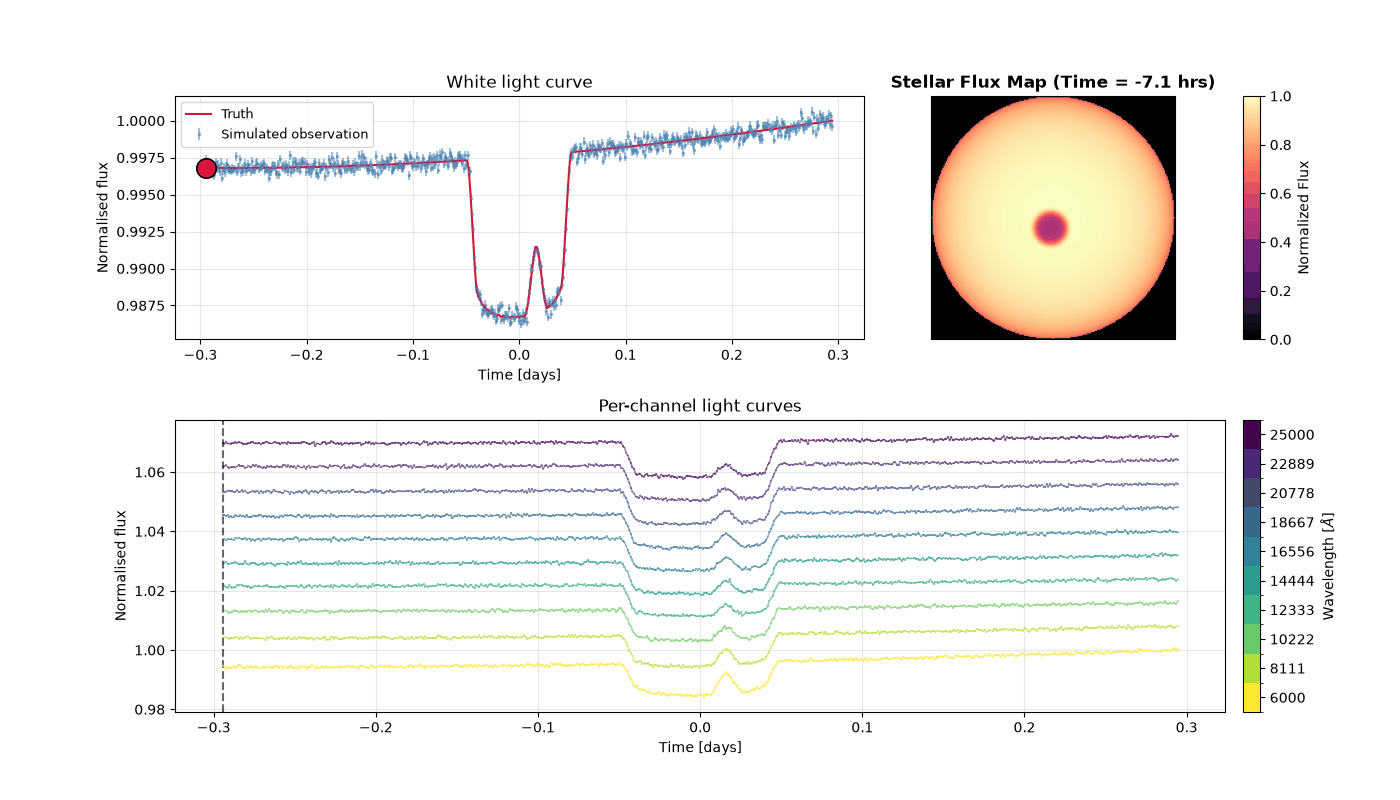

In [5]:
# ---- Plot: white light curve --------------
fig, axes = plt.subplot_mosaic(
    [['A', 'B', 'cbar1'],['C', 'C', 'cbar2']],
    figsize=(14, 8), width_ratios=[2, 1, 0.05], 
    height_ratios=[1,1.2], gridspec_kw={'hspace':0.3, 'wspace':0.05})

axes['A'].errorbar(times, lc_white_obs, yerr=lc_white_err, fmt='.', ms=3, color='steelblue', alpha=0.5, label='Simulated observation')
axes['A'].plot(times, lc_white_true, '-', color='crimson', lw=1.5, label='Truth')
axes['A'].set_xlabel('Time [days]'); axes['A'].set_ylabel('Normalised flux')
axes['A'].set_title('White light curve'); axes['A'].legend(fontsize=9)
phase_marker, = axes['A'].plot([times[0]], [lc_white_true[0]], 'o', markersize=14,
                           color='crimson', markeredgecolor='black',
                           markeredgewidth=1.2, zorder=5)
axes['A'].grid(alpha=0.3)

im_B = axes['B'].imshow(star_maps[0], cmap='magma', origin='lower', vmin=vmin, vmax=vmax)
map_title = axes['B'].set_title(f'Stellar Flux Map (Phase = {times[0]:.0f}°)',
                              fontsize=12, fontweight='bold')
axes['B'].set_xticks([]); axes['B'].set_yticks([])
sm = plt.cm.ScalarMappable(cmap='magma', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=axes['cbar1'], label='Normalized Flux')

# ---- Plot: per-channel light curves --------------
wave_cmap = plt.get_cmap('viridis_r', NWAVE)
wave_edges = np.concatenate([
    [1.5 * wavelength[0] - 0.5 * wavelength[1]],
    (wavelength[:-1] + wavelength[1:]) / 2.0,
    [1.5 * wavelength[-1] - 0.5 * wavelength[-2]],
])   # bin edges halfway between consecutive channels, extended at both ends
wave_norm = BoundaryNorm(wave_edges, wave_cmap.N)
for i in range(NWAVE):
    axes['C'].errorbar(times, lc_2d_obs[:, i] + i*0.008, yerr=lc_2d_err[:, i], fmt='-', lw=1.2, alpha=0.5, color=wave_cmap(wave_norm(wavelength[i])))
axes['C'].set_xlabel('Time [days]'); axes['C'].set_ylabel('Normalised flux')
axes['C'].set_title('Per-channel light curves')
twod_phase_marker = axes['C'].axvline(times[0], color='black', linestyle='--', alpha=0.6)
sm = plt.cm.ScalarMappable(cmap=wave_cmap, norm=wave_norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=axes['cbar2'], ticks=wavelength, label='Wavelength [$\\AA$]')
cbar.ax.set_yticklabels([f'{w:.0f}' for w in wavelength])
axes['C'].grid(alpha=0.3)

def _update(frame):
    phase_marker.set_data([times[frame]], [lc_white_true[frame]])
    twod_phase_marker.set_xdata([times[frame], times[frame]])
    im_B.set_data(star_maps[frame])
    map_title.set_text(f'Stellar Flux Map (Time = {times[frame]*24:.1f} hrs)')
    return phase_marker, twod_phase_marker, im_B, map_title

frame_idx = list(range(0, len(times), 4))
anim = FuncAnimation(fig, _update, frames=frame_idx, interval=80, blit=False)

with tempfile.NamedTemporaryFile(suffix='.gif', delete=False) as _tmp:
    gif_path = _tmp.name
anim.save(gif_path, writer=PillowWriter(fps=15))
plt.close(fig)
with open(gif_path, 'rb') as f:
    gif_bytes = f.read()
os.remove(gif_path)

display(Image(data=gif_bytes, format='gif'))

## Fitting Method

Both stages below can be fit two ways:

* **`"map"`** (default) - a fast maximum a posteriori (MAP) point estimate found via gradient-based optimization (`numpyro_ext.optim`, using `jaxopt`'s L-BFGS under the hood). As this takes only a few seconds-minutes, it keeps the notebook quick to run end-to-end.
  
* **`"nuts"`** - the full posterior via NUTS MCMC, giving real uncertainties and the corner/trace plots below, at the cost of much longer runtime (on the order of hours for the current setup). See the "Runtime tuning" cell further down to learn about the key `SAJAX` knobs to turn to speed this up.

Switch `FIT_METHOD` and re-run from here on to change which one is used.

In [6]:
FIT_METHOD = "map"   # "map" or "nuts"
assert FIT_METHOD in ("map", "nuts")

## Stage 1: White Light Curve Fit - Spot Position & Planet Orbit

The basic modus operandi of `SAJAX` is a two-stage split: build a model once, then evaluate it as many times as you need with different active region (and optionally, transit) parameters. This offers users two alternatives to generating light curves:

* `quick_lc` : a convenience wrapper that builds the model *and* evaluates it in a single call.

* `build_system` + `make_lc` : splits those two costs apart. `build_system` does the expensive, one-time setup (the static stellar grid, orbit geometry, etc...) while `make_lc` is cheap, differentiable, and safe to `jit`/`vmap`/`grad`. For an MCMC, the ideal setup is therefore: build the model *once*, then call `make_lc` as many times as needed at different parameter values.

Note : Sampling limb-darkening coefficients can be tricky. Thankfully, we can use the `QuadLDParams` distribution from the `numpyro_ext` package which implements the transformation for quadratic limb-darkening coefficients specified by [Kipping (2013)](https://doi.org/10.1093/mnras/stt1435). Through this transformation, we sample coefficients $q_1$ and $q_2$ (instead of $u_1$ and $u_2$) from the unit square $[0, 1]$ which enforce the physicality of generated intensity profiles.

In [7]:
# Just so we have a reference truth value for the limb-darkening coefficients and the contrast,
# we replace the white light curve with the light curve at the central wavelength
central_wave_idx = int(len(wavelength)/2)
central_wave = wavelength[central_wave_idx]
flux_quiet_white = spec_quiet[central_wave_idx]
flux_active_white = spec_active[central_wave_idx]
contrast_white = flux_active_white/flux_quiet_white
k_white = k_wavelength[central_wave_idx]
u1_white = u1_wavelength[central_wave_idx]
u2_white = u2_wavelength[central_wave_idx]

# Build the white light curve's model once
white_model = build_system(
    wavelength        =central_wave, 
    flux_quiet        =1.0,
    ld_coeffs         =[0.5, 0.5],        # placeholder -- always overridden per-channel below
    inc_star          =INC_STAR_TRUE,
    times             =times, 
    P_rot             =P_ROT_TRUE,
    t0                =T0_TRUE, 
    period            =PERIOD_TRUE,       # placeholder -- always overridden per-channel below
    a_over_rstar      =A_OVER_RSTAR_TRUE, # placeholder -- always overridden per-channel below
    inclination       =INCLINATION_TRUE,  # placeholder -- always overridden per-channel below
    k                 =k_white,           # placeholder -- always overridden per-channel below
    ecc               =ECC_TRUE, 
    omega_peri        =OMEGA_TRUE,
    stellar_grid_size =STELLAR_GRID, 
    ve                =VE, 
    ld_mode           ="quadratic",
    oversample        =2,
)

# Define the forward model for the white light curve
def model_white(yerr, y=None):

    # Priors for the parameters we're fitting for
    # Active region latitude
    sin_ar_lat = numpyro.sample("sin_ar_lat", dist.Uniform(-1., 1.))

    # Active region longitude
    ar_long = numpyro.sample("ar_long", dist.Uniform(-180., 180.))

    # Active region size
    ar_size = numpyro.sample("ar_size", dist.Uniform(5., 45.))

    # Active region contrast
    ar_contrast = numpyro.sample("ar_contrast", dist.Uniform(0., 2.))

    # Orbital period
    period = numpyro.sample("period", dist.Normal(PERIOD_TRUE, 0.0005))

    # Semi-major axis
    a_over_rstar = numpyro.sample("a_over_rstar", dist.Uniform(0., 50.))

    # Inclination
    inclination = numpyro.sample("inclination", dist.Uniform(jnp.deg2rad(70.), jnp.deg2rad(110.)))

    # Planet-to-star radius ratio
    k = numpyro.sample("k", dist.Uniform(0., 1.))

    # Limb-darkening coefficients
    u = numpyro.sample("u", ext_dist.QuadLDParams())

    #Light curve
    y_pred = make_lc(
        white_model,
        flux_active      =ar_contrast,
        ld_coeffs_quiet  =jnp.asarray([u]),
        ar_lat           =jnp.rad2deg(jnp.arcsin(sin_ar_lat)),
        ar_long          =ar_long,
        ar_size          =ar_size,
        period           =period,
        a_over_rstar     =a_over_rstar,
        inclination      =inclination,
        k                =k,
        ar_smoothness    =AR_SMOOTH_TRUE,
        t0               =T0_TRUE,
        transit_softness =SOFTNESS,
    )[0]
    y_pred = y_pred / jnp.max(y_pred)   # Normalise to unity

    # Track the light curve
    numpyro.deterministic("light_curve", y_pred)

    # The likelihood function assuming Gaussian uncertainty
    numpyro.sample("obs", dist.Normal(y_pred, yerr), obs=y)

# Bounds from which to sample the initial position
INIT_POSITIONS_BOUNDS = {
    "sin_ar_lat":    [jnp.sin(jnp.deg2rad(AR_LAT_TRUE - 10.)), jnp.sin(jnp.deg2rad(AR_LAT_TRUE + 10.))],
    "ar_long":       [AR_LONG_TRUE - 10., AR_LONG_TRUE + 10.],
    "ar_size":       [jnp.maximum(AR_SIZE_TRUE - 5., 0.), AR_SIZE_TRUE + 5.],
    "ar_contrast":   [jnp.maximum(contrast_white - 0.2, 0.), contrast_white + 0.2],
    "period":        [PERIOD_TRUE - 0.0005, PERIOD_TRUE + 0.0005],
    "a_over_rstar":  [A_OVER_RSTAR_TRUE - 2., A_OVER_RSTAR_TRUE + 2.],
    "inclination":   [INCLINATION_TRUE - jnp.deg2rad(5.), INCLINATION_TRUE + jnp.deg2rad(5.)],
    "k":             [jnp.maximum(k_white - 0.03, 0.), k_white + 0.03],
}
# Initial positions
init_pos_key = jax.random.PRNGKey(12)
init_pos = {
    name: jax.random.uniform(init_pos_key, minval=lo, maxval=hi)
    for name, (lo, hi) in INIT_POSITIONS_BOUNDS.items()
}
init_pos["u"] = jnp.array([u1_white + 0.2, u2_white - 0.2])

if FIT_METHOD == "nuts":
    # Full posterior via NUTS MCMC
    sampler_white = numpyro.infer.MCMC(
        numpyro.infer.NUTS(
            model_white,
            dense_mass=True,
            regularize_mass_matrix=True,
            init_strategy=numpyro.infer.init_to_value(values=init_pos),
        ),
        num_warmup=100,
        num_samples=400,
        num_chains=2,
        progress_bar=True,
    )
    sampler_white.run(jax.random.PRNGKey(0), jnp.asarray(lc_white_err), 
                      y=jnp.asarray(lc_white_obs), extra_fields=("potential_energy",))
else:
    # MAP point estimate via gradient-based optimization.
    run_geom = optimx.optimize(
        model_white,
        sites=["sin_ar_lat", "ar_long", "ar_size", "period", "a_over_rstar", "inclination", "k"],
        start=init_pos,
    )
    soln_geom = run_geom(jax.random.PRNGKey(0), jnp.asarray(lc_white_err), y=jnp.asarray(lc_white_obs))

    run_joint = optimx.optimize(model_white, start={name: soln_geom[name] for name in init_pos})
    soln_white = run_joint(jax.random.PRNGKey(1), jnp.asarray(lc_white_err), y=jnp.asarray(lc_white_obs))

## Summary and Traces

With `FIT_METHOD = "nuts"`, this prints NumPyro's own posterior summary (mean/std/HDI/ESS/r_hat per parameter) and plots the trace -- one panel per achromatic parameter, showing the posterior density alongside the raw chain traces (useful for spotting non-convergence or stuck chains).

With `FIT_METHOD = "map"`, there's no posterior to summarize -- instead this just prints each parameter's MAP estimate next to its ground-truth value.

In [8]:
if FIT_METHOD == "nuts":
    # Formatting samples
    inf_data = az.from_numpyro(sampler_white)
    inf_data.posterior["ar_lat"] = np.rad2deg(np.arcsin(inf_data.posterior["sin_ar_lat"].clip(-1.0, 1.0)))
    inf_data.posterior["inclination"] = np.rad2deg(inf_data.posterior["inclination"])
    inf_data.posterior["u1"] = inf_data.posterior["u"].isel(u_dim_0=0)
    inf_data.posterior["u2"] = inf_data.posterior["u"].isel(u_dim_0=1)

    # Making nice display names for the parameters in the corner plot and ArviZ summary
    display_names = {
        "ar_lat": r"$\phi_{\rm ar}$ [deg]", "ar_long": r"$\lambda_{\rm ar}$ [deg]",
        "ar_size": r"$r_{\rm ar}$ [deg]", "ar_contrast": r"$C_{\rm ar}$",
        "period": r"$P$ [days]", "a_over_rstar": r"$a/R_{\star}$",
        "inclination": r"$i$ [deg]", "k": r"$R_p/R_{\star}$",
        "u1": r"$u_1$", "u2": r"$u_2$",
    }
    inf_data.posterior = inf_data.posterior[list(display_names)].rename(display_names)
    param_names = list(display_names.values())

    # Showing summary
    sampler_white.print_summary()

    # Plotting traces
    _ = az.plot_trace(
        inf_data,
        var_names=param_names,
        backend_kwargs={"constrained_layout": True},
    )
else:
    # MAP: no posterior to summarize/trace over -- report the point
    # estimate against the ground truth for each fitted parameter instead.
    map_summary = {
        "ar_lat [deg]":      (float(jnp.rad2deg(jnp.arcsin(soln_white["sin_ar_lat"]))), AR_LAT_TRUE),
        "ar_long [deg]":     (float(soln_white["ar_long"]), AR_LONG_TRUE),
        "ar_size [deg]":     (float(soln_white["ar_size"]), AR_SIZE_TRUE),
        "ar_contrast":       (float(soln_white["ar_contrast"]), float(contrast_white)),
        "period [days]":     (float(soln_white["period"]), PERIOD_TRUE),
        "a_over_rstar":      (float(soln_white["a_over_rstar"]), A_OVER_RSTAR_TRUE),
        "inclination [deg]": (float(jnp.rad2deg(soln_white["inclination"])), float(np.rad2deg(INCLINATION_TRUE))),
        "k":                 (float(soln_white["k"]), float(k_white)),
        "u1":                (float(soln_white["u"][0]), float(u1_white)),
        "u2":                (float(soln_white["u"][1]), float(u2_white)),
    }
    print(f"{'parameter':<18s}{'MAP':>12s}{'truth':>12s}")
    for name, (map_val, truth_val) in map_summary.items():
        print(f"{name:<18s}{map_val:>12.4f}{truth_val:>12.4f}")

    # Fit quality check
    rv_map_pred = jnp.asarray(soln_white["light_curve"])
    chi2_map   = float(jnp.sum(((jnp.asarray(lc_white_obs) - rv_map_pred) / SIGMA) ** 2))
    chi2_truth = float(jnp.sum(((jnp.asarray(lc_white_obs) - lc_white_true) / SIGMA) ** 2))
    print(f"\nchi^2 at MAP:   {chi2_map:.1f}  ({len(lc_white_obs)} points)")
    print(f"chi^2 at truth: {chi2_truth:.1f}")

parameter                  MAP       truth
ar_lat [deg]           13.2733      5.0000
ar_long [deg]          20.4054     20.0000
ar_size [deg]           8.0634      8.0000
ar_contrast             0.3884      0.4854
period [days]           4.2000      4.2000
a_over_rstar           14.8665     15.0000
inclination [deg]      89.3930     90.0000
k                       0.0992      0.1006
u1                      0.0765      0.0964
u2                      0.3314      0.2768

chi^2 at MAP:   653.5  (600 points)
chi^2 at truth: 656.8


## Corner Plot and Best-fit Light Curves

With `FIT_METHOD = "nuts"`, this shows the full posterior corner plot (with truth/posterior-median/MAP marked on every panel), followed by the best-fit light curve, residuals, and a rotating stellar-flux-map animation at the posterior-median (and MAP) parameters.

With `FIT_METHOD = "map"`, the corner plot is skipped -- there's no distribution to show, just a single point estimate -- straight to the best-fit light curve, residuals, and star-map animation at the MAP parameters.

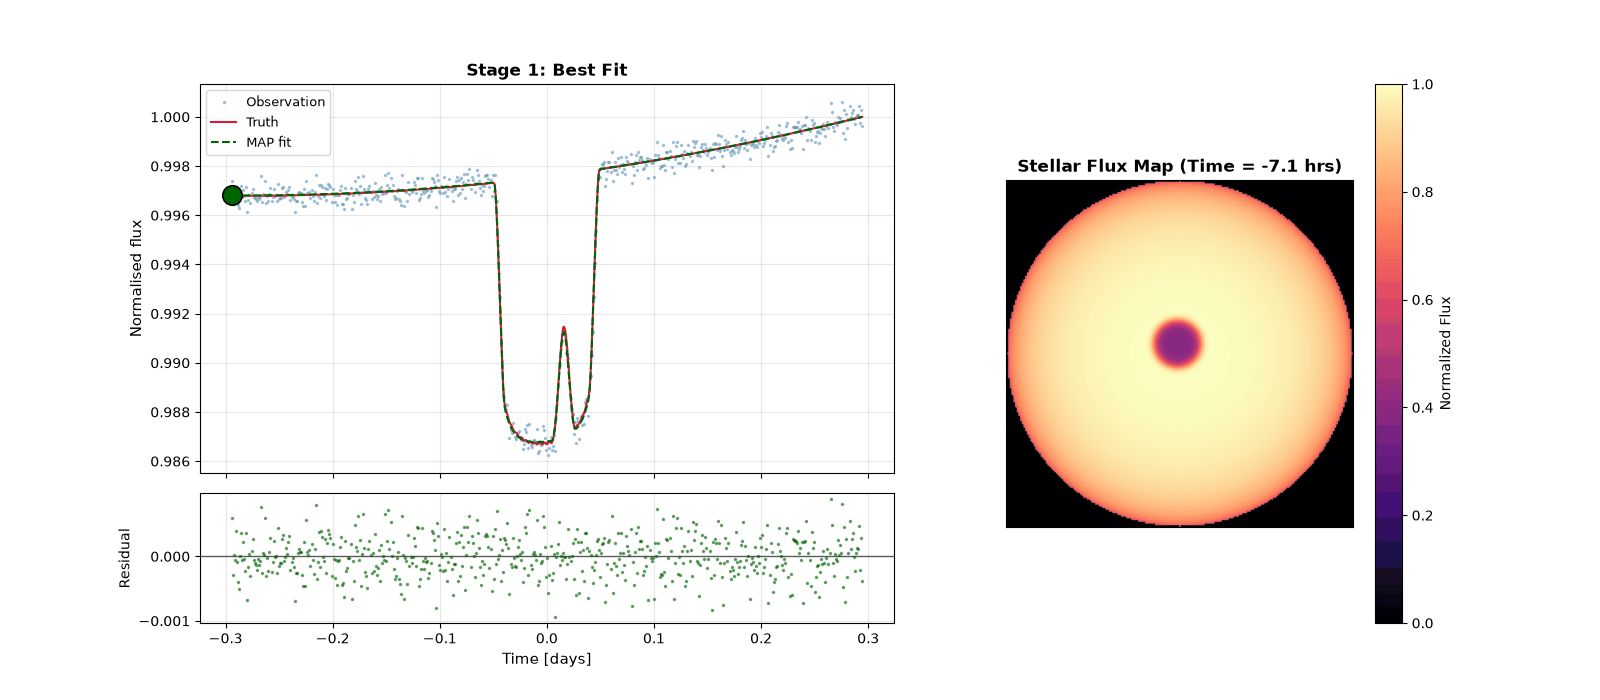

In [9]:
if FIT_METHOD == "nuts":
    # Build a dictionary for the true parameter values
    truths_white = dict(
        ar_lat=AR_LAT_TRUE, ar_long=AR_LONG_TRUE, ar_size=AR_SIZE_TRUE,
        ar_contrast=contrast_white, period=PERIOD_TRUE, a_over_rstar=A_OVER_RSTAR_TRUE,
        inclination=np.rad2deg(INCLINATION_TRUE), k=k_white, u=jnp.array([u1_white, u2_white]),
    )

    # Retrieve the samples, and MAP index from the sampler
    samples_white = sampler_white.get_samples()
    map_idx_white = int(np.argmin(np.array(sampler_white.get_extra_fields()["potential_energy"])))

    # ---- Corner plot with truth/median/MAP overlaid on every panel ----
    # Convert the raw samples into a dictionary of arrays for corner
    # Post-process the ar_lat and inclination samples into degrees for display purposes only
    corner_samples = {
        "ar_lat":       np.rad2deg(np.arcsin(np.clip(np.array(samples_white["sin_ar_lat"]), -1.0, 1.0))),
        "ar_long":      np.array(samples_white["ar_long"]),
        "ar_size":      np.array(samples_white["ar_size"]),
        "ar_contrast":  np.array(samples_white["ar_contrast"]),
        "period":       np.array(samples_white["period"]),
        "a_over_rstar": np.array(samples_white["a_over_rstar"]),
        "inclination":  np.rad2deg(np.array(samples_white["inclination"])),
        "k":            np.array(samples_white["k"]),
    }
    # Convert q1 and q2 to u1 and u2 for corner
    corner_samples["u1"] = np.array(samples_white["u"])[:, 0]
    corner_samples["u2"] = np.array(samples_white["u"])[:, 1]
    corner_truths = {name: truths_white[name] for name in corner_samples if name not in ("u1", "u2")}
    corner_truths["u1"] = u1_white
    corner_truths["u2"] = u2_white

    # Format the parameter names and arrays for the corner plot
    samples_arr = np.stack([corner_samples[name] for name in corner_samples.keys()], axis=-1)
    truths_arr  = [float(corner_truths[name]) for name in corner_samples.keys()]
    median_arr  = [float(np.median(corner_samples[name])) for name in corner_samples.keys()]
    map_arr     = [float(corner_samples[name][map_idx_white]) for name in corner_samples.keys()]

    # Generate corner plot
    fig = corner.corner(
        samples_arr, labels=param_names, truths=truths_arr,
        show_titles=True, title_fmt='.4f',
        label_kwargs={'fontsize': 14}, title_kwargs={'fontsize': 11},
    )

    # Overplot the median and MAP values
    corner.overplot_lines(fig, median_arr, color='darkorange', linestyle='--', linewidth=1.2)
    corner.overplot_points(fig, [median_arr], marker='s', color='darkorange', markersize=6)
    corner.overplot_lines(fig, map_arr, color='mediumseagreen', linestyle='-.', linewidth=1.2)
    corner.overplot_points(fig, [map_arr], marker='D', color='mediumseagreen', markersize=6)

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color='#4682b4', label='Truth'),
        Line2D([0], [0], color='darkorange', linestyle='--', label='Posterior median'),
        Line2D([0], [0], color='mediumseagreen', linestyle='-.', label='MAP'),
    ]
    fig.legend(handles=legend_handles, loc='upper right', fontsize=14, bbox_to_anchor=(0.98, 0.98))
    plt.show()

    # Posterior-median and MAP light curves + residuals
    lc_samples_white         = jnp.array(samples_white["light_curve"])   # (num_samples, ntimes)
    lc_bestfit_white         = jnp.median(lc_samples_white, axis=0)
    lc_map_white             = lc_samples_white[map_idx_white]
    residuals_bestfit_white  = jnp.array(lc_white_obs) - lc_bestfit_white
    residuals_map_white      = jnp.array(lc_white_obs) - lc_map_white

    # The achromatic point estimate handed to Stage 2: posterior medians here
    median_white = {name: float(jnp.median(arr)) for name, arr in samples_white.items() if arr.ndim == 1}
    u1_median, u2_median = (float(x) for x in jnp.median(jnp.array(samples_white["u"]), axis=0))
    median_white["ar_lat"] = jnp.rad2deg(jnp.arcsin(median_white["sin_ar_lat"]))
else:
    # MAP point estimate light curve + residuals
    u1_median, u2_median = float(soln_white["u"][0]), float(soln_white["u"][1])
    median_white = {
        "ar_lat":       float(jnp.rad2deg(jnp.arcsin(soln_white["sin_ar_lat"]))),
        "ar_long":      float(soln_white["ar_long"]),
        "ar_size":      float(soln_white["ar_size"]),
        "ar_contrast":  float(soln_white["ar_contrast"]),
        "period":       float(soln_white["period"]),
        "a_over_rstar": float(soln_white["a_over_rstar"]),
        "inclination":  float(soln_white["inclination"]),
        "k":            float(soln_white["k"]),
    }
    lc_bestfit_white        = jnp.array(soln_white["light_curve"])   # (ntimes,) -- straight from the model
    residuals_bestfit_white = jnp.array(lc_white_obs) - lc_bestfit_white

# ---- Best-fit star map + light curve (shared by both fitting methods) ----
result_bestfit = make_lc(
    white_model,
    flux_active      =median_white["ar_contrast"],
    ld_coeffs_quiet  =jnp.asarray([[u1_median, u2_median]]),
    ar_lat           =median_white["ar_lat"],
    ar_long          =median_white["ar_long"],
    ar_size          =median_white["ar_size"],
    ar_smoothness    =AR_SMOOTH_TRUE,
    period           =max(median_white["period"], 1e-3),
    a_over_rstar     =median_white["a_over_rstar"],
    inclination      =median_white["inclination"],
    k                =median_white["k"],
    t0               =T0_TRUE,
    transit_softness =SOFTNESS,
)
star_maps_bestfit = jnp.asarray(result_bestfit[1])
vmin_bf, vmax_bf  = float(star_maps_bestfit.min()), float(star_maps_bestfit.max())

#Plotting
fig, axes = plt.subplot_mosaic(
    [['LC', 'MAP'], ['RESID', 'MAP']],
    figsize=(16, 7), height_ratios=[3, 1], width_ratios=[1.6, 1],
    gridspec_kw={'hspace': 0.08}, sharex=False,
)
ax_lc, ax_resid, ax_map = axes['LC'], axes['RESID'], axes['MAP']

# Light curve panel with the truth, noisy observations, and best fit
ax_lc.plot(times, lc_white_obs, '.', ms=3, color='steelblue', alpha=0.4, label='Observation')
ax_lc.plot(times, lc_white_true, '-', color='crimson', lw=1.5, label='Truth')
ax_lc.plot(times, lc_bestfit_white, '--', color='darkgreen', lw=1.5,
           label='Posterior-median fit' if FIT_METHOD == 'nuts' else 'MAP fit')
if FIT_METHOD == 'nuts':
    ax_lc.plot(times, lc_map_white, '-.', color='mediumseagreen', lw=1.5, label='MAP fit')
phase_marker, = ax_lc.plot([times[0]], [lc_bestfit_white[0]], 'o', markersize=14,
                           color='darkgreen', markeredgecolor='black',
                           markeredgewidth=1.2, zorder=5)
ax_lc.set_ylabel('Normalised flux', fontsize=11)
ax_lc.set_title('Stage 1: Best Fit', fontsize=12, fontweight='bold')
ax_lc.legend(fontsize=9); ax_lc.grid(alpha=0.3)
ax_lc.tick_params(labelbottom=False)
ax_lc.sharex(ax_resid)

# Residuals panel
ax_resid.axhline(0.0, color='black', lw=1.0, alpha=0.6)
ax_resid.plot(times, residuals_bestfit_white, '.', ms=3, color='darkgreen', alpha=0.5)
if FIT_METHOD == 'nuts':
    ax_resid.plot(times, residuals_map_white, '.', ms=3, color='mediumseagreen', alpha=0.5)
ax_resid.set_xlabel('Time [days]', fontsize=11); ax_resid.set_ylabel('Residual', fontsize=10)
ax_resid.grid(alpha=0.3)

# Stellar surface map panel
im = ax_map.imshow(star_maps_bestfit[0], cmap='magma', origin='lower', vmin=vmin_bf, vmax=vmax_bf)
map_title = ax_map.set_title(f'Stellar Flux Map (Time = {times[0]*24:.1f} hrs)',
                              fontsize=12, fontweight='bold')
ax_map.set_xticks([]); ax_map.set_yticks([])
plt.colorbar(im, ax=ax_map, label='Normalized Flux')

def _update(frame):
    phase_marker.set_data([times[frame]], [lc_bestfit_white[frame]])
    im.set_data(star_maps_bestfit[frame])
    map_title.set_text(f'Stellar Flux Map (Time = {times[frame]*24:.1f} hrs)')
    return phase_marker, im, map_title
frame_idx = list(range(0, len(times), 4))
anim = FuncAnimation(fig, _update, frames=frame_idx, interval=80, blit=False)

with tempfile.NamedTemporaryFile(suffix='.gif', delete=False) as _tmp:
    gif_path = _tmp.name
anim.save(gif_path, writer=PillowWriter(fps=30))
plt.close(fig)
with open(gif_path, 'rb') as f:
    gif_bytes = f.read()
os.remove(gif_path)

display(Image(data=gif_bytes, format='gif'))

## Stage 2: Joint Per-Channel Chromatic Fit

Achromatic geometry/orbit are fixed at the Stage-1 posterior median values. Three things are sampled, each a `(NWAVE,)` array rather than a single scalar:

- **`u`** - the quiet photosphere's limb-darkening coefficients `(u1, u2)`, sampled with the Kipping parametrization on the interval `[0, 1]`.
  
- **`contrast`** - the spot's darkness, relative to the quiet photosphere.
  
- **`k`** - the planet-to-star radius ratio, which directly provides the transmission spectrum.

Because `make_lc` accepts `u`/`k`/`ld_coeffs_quiet` as `(nwave,)` arrays directly, this is a **single** NUTS run over batched parameters, comparing one predicted `(ntimes, nwave)` light curve against the full `lc_2d_obs`.

In [10]:
# ---- Fixed achromatic parameters for Stage 2, from the Stage 1 posterior ----
FIXED_AR_LAT       = median_white["ar_lat"]
FIXED_AR_LONG      = median_white["ar_long"]
FIXED_AR_SIZE      = median_white["ar_size"]
FIXED_PERIOD       = median_white["period"]
FIXED_A_OVER_RSTAR = median_white["a_over_rstar"]
FIXED_INCLINATION  = median_white["inclination"]

print("Fixed for Stage 2 (Stage 1 posterior medians):")
print(f"  ar_lat={FIXED_AR_LAT:.3f}, ar_long={FIXED_AR_LONG:.3f}, ar_size={FIXED_AR_SIZE:.3f}")
print(f"  period={FIXED_PERIOD:.4f}, "
      f"a_over_rstar={FIXED_A_OVER_RSTAR:.3f}, inclination={FIXED_INCLINATION:.4f}")

Fixed for Stage 2 (Stage 1 posterior medians):
  ar_lat=13.273, ar_long=20.405, ar_size=8.063
  period=4.2000, a_over_rstar=14.867, inclination=1.5602


## Runtime tuning

Two knobs dominate wall-clock time more than the number of wavelengths or the number of sampled parameters, so they're the first things to reach for if a Stage 2 fit feel too slow:

* *`stellar_grid_size`* — every phase and every wavelength channel touches all $\sim \pi R_{\star}^2$ in-disc pixels, so cost naively scales quadratically with $R_{\star}$. 
  
* *`oversample`* — each sub-exposure is a full extra pass through the pixel grid, so cost scales linearly.

**For both of these, reduce their value while fitting, and only bump it back up for the final high-resolution star-map visualization.**

In [11]:
# Build the full NWAVE-wavelength model once
model_2d = build_system(
    wavelength        = wavelength,
    flux_quiet        = spec_quiet,
    ld_coeffs         = [0.5, 0.5],           # placeholder -- always overridden per-channel below
    inc_star          = INC_STAR_TRUE,
    times             = times,
    P_rot             = P_ROT_TRUE,
    t0                = T0_TRUE,
    period            = FIXED_PERIOD,
    a_over_rstar      = FIXED_A_OVER_RSTAR,
    inclination       = FIXED_INCLINATION,
    k                 = median_white["k"],    # placeholder -- always overridden per-channel below
    ecc               = ECC_TRUE,
    omega_peri        = OMEGA_TRUE,
    stellar_grid_size = STELLAR_GRID/2,
    ve                = VE,
    ld_mode           = "quadratic",
    oversample        = 2,
)

# Define the forward model for the chromatic light curve.
def numpyro_model_2d(yerr, y=None):

    # Priors for the parameters we're fitting for
    # Active region contrast
    ar_contrast = numpyro.sample("ar_contrast", dist.Uniform(0., 2.).expand([NWAVE]))

    # Planet-to-star radius ratio
    k = numpyro.sample("k", dist.Uniform(0., 1.).expand([NWAVE]))

    # Limb-darkening coefficients
    u = numpyro.sample("u", ext_dist.QuadLDParams().expand([NWAVE]))

    #Light curve
    y_pred = make_lc(
        model_2d,
        flux_active      =ar_contrast * spec_quiet,
        ld_coeffs_quiet  =u,   
        ar_lat           =FIXED_AR_LAT,
        ar_long          =FIXED_AR_LONG,
        ar_size          =FIXED_AR_SIZE,
        ar_smoothness    =AR_SMOOTH_TRUE,
        t0               =T0_TRUE,
        period           =FIXED_PERIOD,
        a_over_rstar     =FIXED_A_OVER_RSTAR,
        inclination      =FIXED_INCLINATION,
        k                =k,
        transit_softness =SOFTNESS,
    )[0]   # (ntimes, nwave)
    y_pred = y_pred / jnp.max(y_pred, axis=0)   # Normalise to unity per channel

    # Track the light curve
    numpyro.deterministic("light_curve", y_pred)

    # The likelihood function assuming Gaussian uncertainty
    numpyro.sample("obs", dist.Normal(y_pred, yerr), obs=y)

# Bounds from which to sample the initial position
INIT_POSITIONS_BOUNDS = {
    "ar_contrast": [jnp.maximum(spec_active/spec_quiet - 0.2, 0.), spec_active/spec_quiet + 0.2],
    "k":           [jnp.maximum(median_white["k"] - 0.03, 0.), median_white["k"] + 0.03],
}
# Initial positions
init_pos_2d_key = jax.random.PRNGKey(12)
init_pos_2d = {
    # Explicit shape=(NWAVE,) so this works whether the bounds themselves
    # are per-channel arrays (ar_contrast) or shared scalars (k) -- without
    # it, jax.random.uniform can't infer a (NWAVE,)-shaped output.
    name: jax.random.uniform(init_pos_2d_key, shape=(NWAVE,), minval=lo, maxval=hi)
    for name, (lo, hi) in INIT_POSITIONS_BOUNDS.items()
}
init_pos_2d["u"] = jnp.stack([u1_wavelength + 0.2, u2_wavelength - 0.2], axis=-1)

if FIT_METHOD == "nuts":
    # Sampling
    sampler_2d = numpyro.infer.MCMC(
        numpyro.infer.NUTS(
            numpyro_model_2d,
            # Diagonal, not dense: with NWAVE channels x 3 sampled
            # quantities each, this model has ~4*NWAVE weakly-coupled
            # dimensions (channels barely correlate -- they only share the
            # fixed achromatic geometry). A dense mass matrix needs far
            # more warmup draws than num_warmup below to estimate reliably;
            # with too few, some channels' parameters can get numerically
            # stuck at their init value instead of exploring.
            dense_mass=False,
            regularize_mass_matrix=True,
            init_strategy=numpyro.infer.init_to_value(values=init_pos_2d),
        ),
        num_warmup=100,
        num_samples=400,
        num_chains=2,
        progress_bar=True,
    )
    sampler_2d.run(jax.random.PRNGKey(0), jnp.asarray(lc_2d_err), 
                      y=jnp.asarray(lc_2d_obs), extra_fields=("potential_energy",))
else:
    # MAP point estimate
    run_depth_2d = optimx.optimize(
        numpyro_model_2d, sites=["ar_contrast", "k"], start=init_pos_2d,
    )
    soln_2d_depth = run_depth_2d(jax.random.PRNGKey(0), jnp.asarray(lc_2d_err), y=jnp.asarray(lc_2d_obs))

    run_joint_2d = optimx.optimize(
        numpyro_model_2d, start={name: soln_2d_depth[name] for name in init_pos_2d},
    )
    soln_2d = run_joint_2d(jax.random.PRNGKey(1), jnp.asarray(lc_2d_err), y=jnp.asarray(lc_2d_obs))

## Summary and Traces

With `FIT_METHOD = "nuts"`, this prints the full posterior summary table (every parameter, at every one of the `NWAVE` channels, all at once) and animates the trace plot as a GIF, one frame per wavelength channel.

With `FIT_METHOD = "map"`, this instead prints a per-channel table of MAP estimates against the ground truth.

In [14]:
if FIT_METHOD == "nuts":
    # Formatting samples
    inf_data = az.from_numpyro(sampler_2d)
    inf_data.posterior["u1"] = inf_data.posterior["u"].isel(u_dim_1=0)
    inf_data.posterior["u2"] = inf_data.posterior["u"].isel(u_dim_1=1)
    inf_data.posterior = inf_data.posterior.rename_dims(
        {"ar_contrast_dim_0": "channel", "k_dim_0": "channel", "u_dim_0": "channel"}
    )
    inf_data.posterior = inf_data.posterior.drop_vars(
        ["ar_contrast_dim_0", "k_dim_0", "u_dim_0"], errors="ignore"
    )
    inf_data.posterior = inf_data.posterior.assign_coords(channel=("channel", np.arange(NWAVE)))

    # Making nice display names for the parameters in the corner plot and ArviZ summary
    display_names = {
        "ar_contrast": r"$C_{\rm ar}$",
        "k": r"$R_p/R_{\star}$",
        "u1": r"$u_1$", "u2": r"$u_2$",
    }
    inf_data.posterior = inf_data.posterior[list(display_names)].rename(display_names)
    param_names = list(display_names.values())

    # Showing summary
    sampler_2d.print_summary()

    # ---- Trace plot as a GIF: one frame per wavelength channel ----
    trace_frames = []
    for i in range(NWAVE):
        axes_i = az.plot_trace(
            inf_data, var_names=param_names, coords={"channel": [i]},
            backend_kwargs={"constrained_layout": True},
        )
        fig_i = axes_i.ravel()[0].figure
        fig_i.suptitle(f'Wavelength = {wavelength[i]:.0f} $\\AA$ (channel {i})',
                        fontsize=13, fontweight='bold')
        buf = io.BytesIO()
        fig_i.savefig(buf, format='png', dpi=100)
        buf.seek(0)
        trace_frames.append(PILImage.open(buf).convert('RGB'))
        plt.close(fig_i)

    with tempfile.NamedTemporaryFile(suffix='.gif', delete=False) as _tmp:
        trace_gif_path = _tmp.name
    trace_frames[0].save(trace_gif_path, save_all=True, append_images=trace_frames[1:],
                          duration=700, loop=0)
    with open(trace_gif_path, 'rb') as f:
        trace_gif_bytes = f.read()
    os.remove(trace_gif_path)

    display(Image(data=trace_gif_bytes, format='gif'))
else:
    # MAP: no posterior to summarize/trace over -- a per-channel point
    # estimate vs truth table instead, plus a chi^2 check per channel:
    # comparable chi2 (MAP) and chi2 (true) values mean any parameter-level
    # offset above is a degeneracy (the fit reproduces the data about as
    # well as the true parameters do), not a bad fit.
    lc_2d_pred_map = jnp.asarray(soln_2d["light_curve"])   # (ntimes, nwave)

    print(f"{'channel':<9s}{'wave [A]':>10s}{'C_ar (MAP)':>12s}{'C_ar (true)':>13s}"
          f"{'k (MAP)':>10s}{'k (true)':>10s}{'u1 (MAP)':>10s}{'u1 (true)':>10s}"
          f"{'u2 (MAP)':>10s}{'u2 (true)':>10s}{'chi2 (MAP)':>12s}{'chi2 (true)':>13s}")
    for i in range(NWAVE):
        chi2_map_i  = float(jnp.sum(((jnp.asarray(lc_2d_obs)[:, i] - lc_2d_pred_map[:, i]) / lc_2d_err[:, i]) ** 2))
        chi2_true_i = float(jnp.sum(((jnp.asarray(lc_2d_obs)[:, i] - lc_2d_true[:, i]) / lc_2d_err[:, i]) ** 2))
        print(f"{i:<9d}{wavelength[i]:>10.0f}"
              f"{float(soln_2d['ar_contrast'][i]):>12.4f}{float(spec_active[i]/spec_quiet[i]):>13.4f}"
              f"{float(soln_2d['k'][i]):>10.4f}{float(k_wavelength[i]):>10.4f}"
              f"{float(soln_2d['u'][i, 0]):>10.4f}{float(u1_wavelength[i]):>10.4f}"
              f"{float(soln_2d['u'][i, 1]):>10.4f}{float(u2_wavelength[i]):>10.4f}"
              f"{chi2_map_i:>12.1f}{chi2_true_i:>13.1f}")

channel    wave [A]  C_ar (MAP)  C_ar (true)   k (MAP)  k (true)  u1 (MAP) u1 (true)  u2 (MAP) u2 (true)  chi2 (MAP)  chi2 (true)
0              6000      0.0799       0.1338    0.0965    0.0950    0.2429    0.3287    0.3702    0.3165       624.0        593.8
1              8111      0.2799       0.3079    0.0973    0.0961    0.1318    0.1876    0.3324    0.3129       601.2        575.8
2             10222      0.4244       0.4548    0.0981    0.0972    0.0217    0.1448    0.4379    0.2689       619.0        580.9
3             12333      0.5328       0.5318    0.0988    0.0983    0.1488    0.1312    0.2230    0.2619       607.1        604.1
4             14444      0.4378       0.4618    0.0998    0.0994    0.0224    0.1118    0.4131    0.2772       592.9        590.9
5             16556      0.4637       0.4854    0.1010    0.1006    0.0145    0.0964    0.3818    0.2768       600.8        596.1
6             18667      0.4246       0.4424    0.1020    0.1017    0.0122    0.0909    0.

## Corner Plot and Best-fit Light Curves

With `FIT_METHOD = "nuts"`, the corner plot becomes a GIF -- one frame per wavelength channel, each showing that channel's posterior for contrast/`k`/`u1`/`u2` with truth/posterior-median/MAP marked.

With `FIT_METHOD = "map"`, there's one point (not a distribution) per channel, so instead this plots the recovered transmission spectrum, limb-darkening coefficients, and spot-contrast spectrum against wavelength, each against its ground truth.

Either way, the section ends with all `NWAVE` channels' best-fit light curves and residuals superposed on one plot, colour-coded by wavelength.

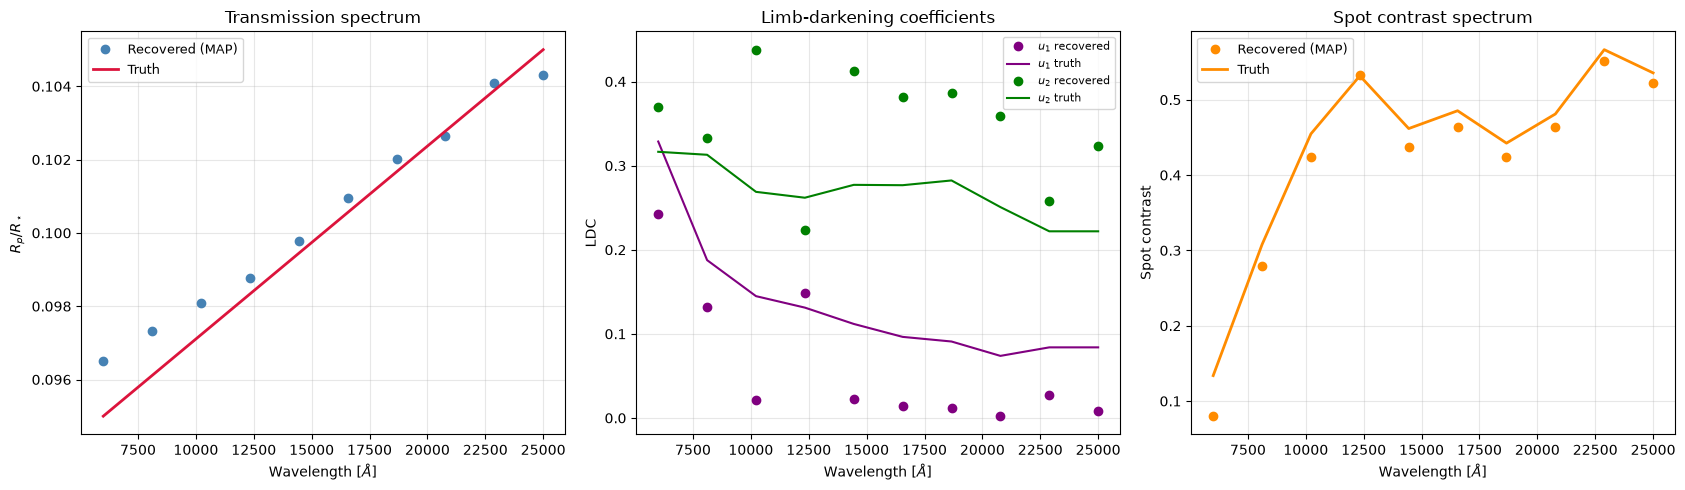

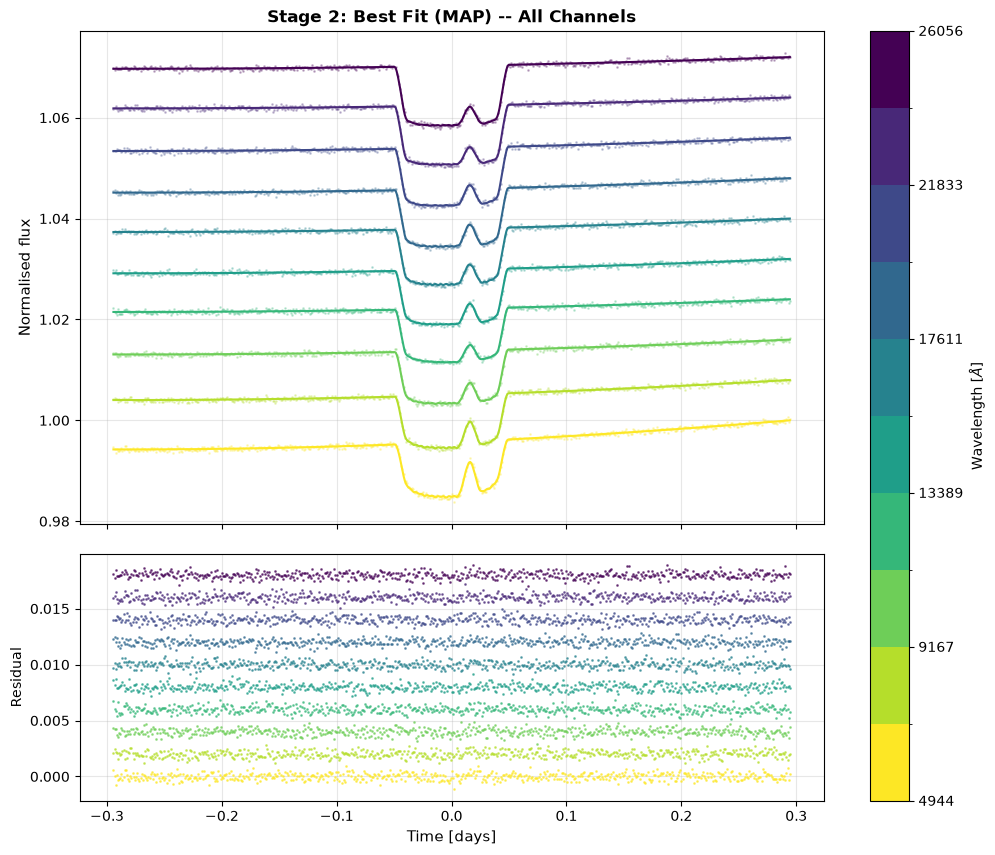

In [15]:
if FIT_METHOD == "nuts":
    # Retrieve the samples, and MAP index from the sampler
    samples_2d = sampler_2d.get_samples()
    map_idx_2d = int(np.argmin(np.array(sampler_2d.get_extra_fields()["potential_energy"])))

    # Per-channel true values, for the truth overlay on each frame
    truths_2d = {
        r"$C_{\rm ar}$":     spec_active / spec_quiet,   # (NWAVE,)
        r"$R_p/R_{\star}$":  k_wavelength,                # (NWAVE,)
        r"$u_1$":            u1_wavelength,                # (NWAVE,)
        r"$u_2$":            u2_wavelength,                # (NWAVE,)
    }

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color='#4682b4', label='Truth'),
        Line2D([0], [0], color='darkorange', linestyle='--', label='Posterior median'),
        Line2D([0], [0], color='mediumseagreen', linestyle='-.', label='MAP'),
    ]

    # ---- Corner plot as a GIF: one frame per wavelength channel ----
    corner_frames = []
    for i in range(NWAVE):
        corner_samples_i = {
            r"$C_{\rm ar}$":     np.array(samples_2d["ar_contrast"])[:, i],
            r"$R_p/R_{\star}$":  np.array(samples_2d["k"])[:, i],
            r"$u_1$":            np.array(samples_2d["u"])[:, i, 0],
            r"$u_2$":            np.array(samples_2d["u"])[:, i, 1],
        }
        names_i       = list(corner_samples_i.keys())
        samples_arr_i = np.stack([corner_samples_i[n] for n in names_i], axis=-1)
        truths_arr_i  = [float(truths_2d[n][i]) for n in names_i]
        median_arr_i  = [float(np.median(corner_samples_i[n])) for n in names_i]
        map_arr_i     = [float(corner_samples_i[n][map_idx_2d]) for n in names_i]

        fig_i = corner.corner(
            samples_arr_i, labels=names_i, truths=truths_arr_i,
            show_titles=True, title_fmt='.4f',
            label_kwargs={'fontsize': 14}, title_kwargs={'fontsize': 11},
        )
        corner.overplot_lines(fig_i, median_arr_i, color='darkorange', linestyle='--', linewidth=1.2)
        corner.overplot_points(fig_i, [median_arr_i], marker='s', color='darkorange', markersize=6)
        corner.overplot_lines(fig_i, map_arr_i, color='mediumseagreen', linestyle='-.', linewidth=1.2)
        corner.overplot_points(fig_i, [map_arr_i], marker='D', color='mediumseagreen', markersize=6)
        fig_i.legend(handles=legend_handles, loc='upper right', fontsize=14, bbox_to_anchor=(0.98, 0.98))
        fig_i.suptitle(f'Stage 2: $\\lambda$ = {wavelength[i]:.0f} $\\AA$ (channel {i})',
                        fontweight='bold', y=1.02)

        buf = io.BytesIO()
        fig_i.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        buf.seek(0)
        corner_frames.append(PILImage.open(buf).convert('RGB'))
        plt.close(fig_i)

    with tempfile.NamedTemporaryFile(suffix='.gif', delete=False) as _tmp:
        corner_gif_path = _tmp.name
    corner_frames[0].save(corner_gif_path, save_all=True, append_images=corner_frames[1:],
                           duration=800, loop=0)
    with open(corner_gif_path, 'rb') as f:
        corner_gif_bytes = f.read()
    os.remove(corner_gif_path)

    display(Image(data=corner_gif_bytes, format='gif'))

    # ---- Best-fit light curves: all NWAVE channels superposed on one plot ----
    lc_samples_2d = np.array(samples_2d["light_curve"])        # (num_samples, ntimes, NWAVE)
    lc_bestfit_2d = np.median(lc_samples_2d, axis=0)            # (ntimes, NWAVE)
else:
    # MAP: a per-channel point estimate vs. truth "recovered spectrum" plot
    # -- the natural MAP-equivalent of the corner-plot/trace-plot GIFs
    # above, since there's one value per channel rather than a distribution.
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    axes[0].plot(wavelength, np.array(soln_2d["k"]), 'o', ms=6, color='steelblue', label='Recovered (MAP)')
    axes[0].plot(wavelength, k_wavelength, '-', color='crimson', lw=2, label='Truth')
    axes[0].set_xlabel('Wavelength [$\\AA$]'); axes[0].set_ylabel(r'$R_p/R_\star$')
    axes[0].set_title('Transmission spectrum'); axes[0].legend(fontsize=9)

    axes[1].plot(wavelength, np.array(soln_2d["u"])[:, 0], 'o', ms=6, color='purple', label='$u_1$ recovered')
    axes[1].plot(wavelength, u1_wavelength, '-', color='purple', lw=1.5, label='$u_1$ truth')
    axes[1].plot(wavelength, np.array(soln_2d["u"])[:, 1], 'o', ms=6, color='green', label='$u_2$ recovered')
    axes[1].plot(wavelength, u2_wavelength, '-', color='green', lw=1.5, label='$u_2$ truth')
    axes[1].set_xlabel('Wavelength [$\\AA$]'); axes[1].set_ylabel('LDC')
    axes[1].set_title('Limb-darkening coefficients'); axes[1].legend(fontsize=8)

    axes[2].plot(wavelength, np.array(soln_2d["ar_contrast"]), 'o', ms=6, color='darkorange', label='Recovered (MAP)')
    axes[2].plot(wavelength, spec_active / spec_quiet, '-', color='darkorange', lw=2, label='Truth')
    axes[2].set_xlabel('Wavelength [$\\AA$]'); axes[2].set_ylabel('Spot contrast')
    axes[2].set_title('Spot contrast spectrum'); axes[2].legend(fontsize=9)

    for ax in axes:
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    lc_bestfit_2d = np.array(soln_2d["light_curve"])   # (ntimes, NWAVE) -- straight from the model

# ---- Best-fit light curves: all NWAVE channels superposed on one plot
# (shared by both fitting methods) ----
residuals_2d = np.array(lc_2d_obs) - lc_bestfit_2d

fig, (ax_lc, ax_resid) = plt.subplots(
    2, 1, figsize=(12, 10), height_ratios=[2, 1], sharex=True,
    gridspec_kw={'hspace': 0.08},
)
for i in range(NWAVE):
    color = wave_cmap(wave_norm(wavelength[i]))
    ax_lc.plot(times, lc_2d_obs[:, i] + i*0.008, '.', ms=2, color=color, alpha=0.25)
    ax_lc.plot(times, lc_bestfit_2d[:, i] + i*0.008, '-', lw=1.5, color=color)
    ax_resid.plot(times, residuals_2d[:, i]  + i*0.002, '.', ms=2, color=color, alpha=0.6)

ax_lc.set_ylabel('Normalised flux', fontsize=11)
ax_lc.set_title(f'Stage 2: Best Fit ({FIT_METHOD.upper()}) -- All Channels', fontsize=12, fontweight='bold')
ax_lc.grid(alpha=0.3)
ax_resid.set_xlabel('Time [days]', fontsize=11); ax_resid.set_ylabel('Residual', fontsize=10)
ax_resid.grid(alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=wave_cmap, norm=wave_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_lc, ax_resid], label='Wavelength [$\\AA$]')
plt.show()